# README:

The outline of sections is below. To replicate, execute them in order.

*   Section 0: Defines pgd_attack and pgd_attack_targeted functions
*   Section 1: Sets up helper functions and network arcitectures, including training and testing for adversarial and standard methods
*   Section 2: Defines hyperparameters and loads data, finds baseline test accuracy, l
*   Section 3a & 3b: Runs Training Loops
*   Section 4: Computes Final Test Accuracy for adversarial and standard
*   Section 5: Finds and saves image of misclassified images

The remaining code is Misc saving and figure generation for the HW questions.

*   Section 6: Saving networks
*   MISC: Loading and Documenting Results

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np


import sys
sys.path.append("..")

import tools.utils as utils
from tools.small_model import FC_MD
from RicciCurvature.OllivierRicci_newW import OllivierRicci
from tools.FC_linear import FC_Linear

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# this should print 'cuda' if you are assigned a GPU
print(device)

cuda


# Section 0: Attack Functions

In [2]:
def pgd_attack(model, image, target, eps=0.1, alpha=0.1, iters=100): 
    # initialize at target image
    adv_image = image.clone()
    adv_image = adv_image.to(device)
    model = model.to(device)
    image = image.to(device)
    target = target.to(device)
    adv_image.requires_grad=True
    
    

    for i in range(iters):

        # eliminate previous gradient values
        model.zero_grad()

        # compute output on current adversarial example
        output = F.log_softmax(model(adv_image), dim=1)

        # use NLL loss
        cost = F.nll_loss(output, target)
        cost.backward()

        # perform projected gradient ascent to maximize loss, 
        # include no_grad to allow in-place update
        with torch.no_grad():
          adv_image = adv_image + alpha*adv_image.grad.sign()
          adv_image = torch.clamp(adv_image, min=image-eps, max=image+eps)
          adv_image = torch.clamp(adv_image, min=0, max=1)

        adv_image.requires_grad = True
        adv_image.detach()
    return adv_image.detach()


def pgd_attack_targeted(model, image, custom_target, eps=0.1, alpha=0.1, iters=100): 
    # initialize at target image
    adv_image = image.clone()
    adv_image = adv_image.to(device)
    model = model.to(device)
    image = image.to(device)
    custom_target = custom_target.to(device)
    adv_image.requires_grad=True

    for i in range(iters):
        # eliminate previous gradient values
        model.zero_grad()

        # compute output on current adversarial example
        output = F.log_softmax(model(adv_image), dim=1)

        # use NLL loss
        cost = F.nll_loss(output, custom_target)
        cost.backward()

        # perform projected gradient descent (to minimize the loss of target class), 
        # include no_grad to allow in-place update
        with torch.no_grad():
          adv_image = adv_image - alpha*adv_image.grad.sign()
          adv_image = torch.clamp(adv_image, min=image-eps, max=image+eps)
          adv_image = torch.clamp(adv_image, min=0, max=1)

        adv_image.requires_grad = True
        adv_image.detach()

    return adv_image.detach()

# Section 1: Import tools, define training and test functions, define network classes

In [3]:
class FC(nn.Module):
    
    def __init__(self, in_dim, out_dim, num_hidden_layers, layer_size):
        super().__init__()

        self.num_layers = num_hidden_layers * 2 + 3 # *2 accounts for ReLU layers, +3 is input layer, input relu layer, output layer

        self.in_dim = in_dim
        self.out_dim = out_dim        

        self.layer_size = layer_size

        self.layer_list = nn.ModuleList()

        self.layer_list.append(nn.Linear(self.in_dim, self.layer_size))
        self.num_hidden_layers = num_hidden_layers

        for i in range(1,self.num_hidden_layers):
            self.layer_list.append(nn.Linear(self.layer_size, self.layer_size))
            

        self.layer_list.append(nn.Linear(self.layer_size, self.out_dim))
        
    def forward(self, x):

        x = x.view(-1, self.in_dim)

        for i in range(self.num_hidden_layers):
            x = F.relu(self.layer_list[i](x))

        return self.layer_list[self.num_hidden_layers](x) 
        
##### SET UP Train and Test function with classes for FC, including adversarial #####
def test(net, loader, device):
    # prepare model for testing (only important for dropout, batch norm, etc.)
    net.eval()
    
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:

            data, target = data.to(device), target.to(device)
            
            output = net(data)
            test_loss += F.nll_loss(output, target, size_average=False).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += (pred.eq(target.data.view_as(pred)).sum().item())
            
            total = total + 1

    print('Test set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(loader.dataset),
        (100. * correct / len(loader.dataset))))
    
    return 100.0 * correct / len(loader.dataset)

def train(net, loader, optimizer, epoch, device, log_interval=100):
    # prepare model for training (only important for dropout, batch norm, etc.)
    net.train()

    correct = 0
    for batch_idx, (data, target) in enumerate(loader):

        data, target = data.to(device), target.to(device)
        
        # clear up gradients for backprop
        optimizer.zero_grad()
        output = F.log_softmax(net(data), dim=1)

        # use NLL loss
        loss = F.nll_loss(output, target)

        # compute gradients and make updates
        loss.backward()
        optimizer.step()

        pred = output.data.max(1, keepdim=True)[1]
        correct += (pred.eq(target.data.view_as(pred)).sum().item())

        if batch_idx % log_interval == 0:
            print('\nTrain Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset), 100. * batch_idx / len(loader), loss.item()))

    print('\tAccuracy: {:.2f}%'.format(100.0 * correct / len(loader.dataset))) 

def test_adversarial(net, loader, device):
    # prepare model for testing (only important for dropout, batch norm, etc.)
    net.eval()
    
    test_loss = 0
    correct = 0
    total = 0


    for data, target in loader:

        data = pgd_attack(net, data, target, eps=.1, alpha=.1, iters=100)
        data, target = data.to(device), target.to(device)

        # compute adversarial example
        
        with torch.no_grad():
          output = net(data)
          test_loss += F.nll_loss(output, target, size_average=False).item()
          pred = output.data.max(1, keepdim=True)[1]
          correct += (pred.eq(target.data.view_as(pred)).sum().item())
        
          total = total + 1

    print('Test set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(loader.dataset),
        (100. * correct / len(loader.dataset))))
    
    return 100.0 * correct / len(loader.dataset)

def train_adversarial(net, loader, optimizer, epoch, device, log_interval=100):
    # prepare model for training (only important for dropout, batch norm, etc.)
    net.train()

    correct = 0
    for batch_idx, (data, target) in enumerate(loader):
        #print(data.size())

        data = pgd_attack(net, data, target, eps=.1, alpha=.1, iters=100).to(device)
        target = target.to(device)
        
        
        # compute adversarial example
        # adv_image = pgd_attack(net, data, target, eps=.1, alpha=.1, iters=100)
        # clear up gradients for backprop
        optimizer.zero_grad()
        output = F.log_softmax(net(data), dim=1)

        # use NLL loss
        loss = F.nll_loss(output, target)

        # compute gradients and make updates
        loss.backward()
        optimizer.step()

        pred = output.data.max(1, keepdim=True)[1]
        correct += (pred.eq(target.data.view_as(pred)).sum().item())

        if batch_idx % log_interval == 0:
            print('\nTrain Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset), 100. * batch_idx / len(loader), loss.item()))

    print('\tAccuracy: {:.2f}%'.format(100.0 * correct / len(loader.dataset))) 

## Build Networks and Load Data

In [132]:
# these are MNIST hyper-parameters.
learning_rate = 1e-2
seed = 100
input_dim = 28 * 28
out_dim = 10
num_hidden_layers = 2
layer_size = 200
momentum = 0.9

#build networks
network = FC_Linear(in_dim=input_dim, out_dim=out_dim, num_hidden_layers=num_hidden_layers, layer_size=layer_size)
network = network.to(device)
#build network
network_basic = FC(in_dim=input_dim, out_dim=out_dim, num_hidden_layers=num_hidden_layers, layer_size=layer_size)
network_basic = network_basic.to(device)


##### LOAD AND Partition Training and test data and PArameters ##### 
transforms = torchvision.transforms.Compose([ torchvision.transforms.ToTensor(),])

# replace MNIST with CIFAR10 to get CIFAR10 data
train_dataset = torchvision.datasets.MNIST('./datasets/', train=True, download=True, transform=transforms)
test_dataset = torchvision.datasets.MNIST('./datasets/', train=False, download=True, transform=transforms)

train_batch_size = 100
test_batch_size = 100
n_epochs = 10
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# sanity check
print('training data size:{}'.format(len(train_loader.dataset)))
print('test data size:{}'.format(len(test_loader.dataset)))

# Sanity check -- output should be close to 10%
print(" \nDetermining Untrained network accuracy:" )
network.to(device)
test(network, test_loader, device)

training data size:60000
test data size:10000
 
Determining Untrained network accuracy:


/usr/local/lib/python3.8/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


Test set: Avg. loss: 0.2584, Accuracy: 683/10000 (6.83%)


6.83

# Section 3a: Adversarial Training 

In [133]:
# training
# set up the optimizer
# SGD is one of the standard implementations of stochastic gradient descent.
network.to(device)
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)
for i in range(n_epochs):
  train_adversarial(network, train_loader, optimizer, i, device, log_interval=100)


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.386781

Train Epoch: 0 [10000/60000 (17%)]	Loss: 2.281735

Train Epoch: 0 [20000/60000 (33%)]	Loss: 1.748889

Train Epoch: 0 [30000/60000 (50%)]	Loss: 1.355345

Train Epoch: 0 [40000/60000 (67%)]	Loss: 1.167145

Train Epoch: 0 [50000/60000 (83%)]	Loss: 1.130526
	Accuracy: 43.58%

Train Epoch: 1 [0/60000 (0%)]	Loss: 1.254178

Train Epoch: 1 [10000/60000 (17%)]	Loss: 1.371819

Train Epoch: 1 [20000/60000 (33%)]	Loss: 0.980128

Train Epoch: 1 [30000/60000 (50%)]	Loss: 1.012198

Train Epoch: 1 [40000/60000 (67%)]	Loss: 0.795335

Train Epoch: 1 [50000/60000 (83%)]	Loss: 0.919934
	Accuracy: 67.78%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.901919

Train Epoch: 2 [10000/60000 (17%)]	Loss: 0.946603

Train Epoch: 2 [20000/60000 (33%)]	Loss: 0.732245

Train Epoch: 2 [30000/60000 (50%)]	Loss: 0.541189

Train Epoch: 2 [40000/60000 (67%)]	Loss: 0.670617

Train Epoch: 2 [50000/60000 (83%)]	Loss: 0.637519
	Accuracy: 74.47%

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.5548

# Section 3b: Normal Training


In [134]:
network_basic.to(device)
optimizer_basic = optim.SGD(network_basic.parameters(), lr=learning_rate, momentum=momentum)
for i in range(n_epochs):
  train(network_basic, train_loader, optimizer_basic, i, device, log_interval=100)


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.302149

Train Epoch: 0 [10000/60000 (17%)]	Loss: 0.920219

Train Epoch: 0 [20000/60000 (33%)]	Loss: 0.360297

Train Epoch: 0 [30000/60000 (50%)]	Loss: 0.292877

Train Epoch: 0 [40000/60000 (67%)]	Loss: 0.516179

Train Epoch: 0 [50000/60000 (83%)]	Loss: 0.295973
	Accuracy: 81.99%

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.238081

Train Epoch: 1 [10000/60000 (17%)]	Loss: 0.248412

Train Epoch: 1 [20000/60000 (33%)]	Loss: 0.317435

Train Epoch: 1 [30000/60000 (50%)]	Loss: 0.186233

Train Epoch: 1 [40000/60000 (67%)]	Loss: 0.236435

Train Epoch: 1 [50000/60000 (83%)]	Loss: 0.306730
	Accuracy: 92.86%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.261778

Train Epoch: 2 [10000/60000 (17%)]	Loss: 0.246647

Train Epoch: 2 [20000/60000 (33%)]	Loss: 0.433846

Train Epoch: 2 [30000/60000 (50%)]	Loss: 0.154856

Train Epoch: 2 [40000/60000 (67%)]	Loss: 0.122502

Train Epoch: 2 [50000/60000 (83%)]	Loss: 0.092337
	Accuracy: 94.92%

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.1601

# Section 4: Testing

In [135]:
print("ADVERSARIALLY TRAINED NETWORK")
network_basic.to(device)
print("Accuracy on Unaltered Test data: \n")
test(network, test_loader, device)
print()
print("Accuracy on adversarial Test data: \n")
test_adversarial(network, test_loader, device)
print()
print("BASIC NETWORK")
print("Accuracy on Unaltered Test data: \n")
test(network_basic, test_loader, device)
print()
print("Accuracy on adversarial Test data: \n")
test_adversarial(network_basic, test_loader, device)
print()

ADVERSARIALLY TRAINED NETWORK
Accuracy on Unaltered Test data: 

Test set: Avg. loss: -93800.6127, Accuracy: 9750/10000 (97.50%)

Accuracy on adversarial Test data: 

Test set: Avg. loss: -69790.3397, Accuracy: 8724/10000 (87.24%)

BASIC NETWORK
Accuracy on Unaltered Test data: 

Test set: Avg. loss: -124903.9056, Accuracy: 9764/10000 (97.64%)

Accuracy on adversarial Test data: 

Test set: Avg. loss: -57421.8134, Accuracy: 1529/10000 (15.29%)



# Section 5: Finding Misclassified Examples

Test set: Avg. loss: -246.3630, Accuracy: 32/10000 (0.32%)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


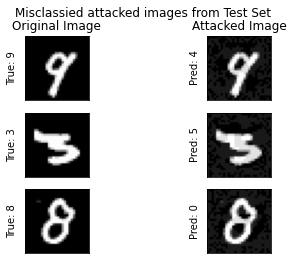

In [136]:
## make function to find misclassified images
def findMisclassified(net, loader, device, num):
    missed = []
    miscount = 0
    # prepare model for testing (only important for dropout, batch norm, etc.)
    net.eval()
    
    test_loss = 0
    correct = 0
    total = 0


    for data, target in loader:

        adv = pgd_attack(net, data, target, eps=.1, alpha=.1, iters=100)
        adv, target = adv.to(device), target.to(device)

        # compute adversarial example
        
        with torch.no_grad():
          output = net(adv)
          test_loss += F.nll_loss(output, target, size_average=False).item()
          pred = output.data.max(1, keepdim=True)[1]
          correct += (pred.eq(target.data.view_as(pred)).sum().item())
          if (pred.item() != target.item()):
            missed.append((data, adv))
            miscount= miscount+1
            if miscount == num:
              break

        
          total = total + 1

    print('Test set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(loader.dataset),
        (100. * correct / len(loader.dataset))))
    
    return missed

one_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)
missed = findMisclassified(network, one_loader, device, 3)

# plot three sample images and save
three_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)
i=0
customtarget = torch.tensor([4])
f, axarr = plt.subplots(3,2)
f.suptitle("Misclassied attacked images from Test Set")
axarr[0,0].set_title("Original Image")
axarr[0,1].set_title("Attacked Image")
for (image, adv) in missed:
    network.cpu()
    adv_image = adv.cpu()
    test_image = image.cpu()
    network.cpu()
    output = F.log_softmax(network(adv_image), dim=1)
    pred = output.data.max(1, keepdim=True)[1]
    output = F.log_softmax(network(test_image), dim=1)
    true = output.data.max(1, keepdim=True)[1]
    axarr[i,0].imshow(test_image[0][0], cmap='gray')
    #axarr[i,0].set_title("Testing Image, label "+str(test_labels.item()))
    axarr[i,0].set_ylabel("True: "+str(true.item()))
    axarr[i,0].set_yticklabels([])
    axarr[i,0].set_xticklabels([])
    axarr[i,0].set_yticks([])
    axarr[i,0].set_xticks([])
    axarr[i,1].imshow(adv_image[0][0].cpu().detach().numpy(), cmap='gray')
    axarr[i,1].set_ylabel("Pred: "+str(pred.item()))
    axarr[i,1].set_yticklabels([])
    axarr[i,1].set_xticklabels([])
    axarr[i,1].set_yticks([])
    axarr[i,1].set_xticks([])
    i+=1
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Colab Notebooks')
plt.savefig("Misclassified images by Adversarial Trained Network.png")





# Section 6: Save Model in Google Drive

This will save the model to your google drive which is preferred since you can load it later without having to retrain (e.g., for future homeworks)

In [137]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Colab Notebooks')

model_path = 'models/'
if not os.path.exists(model_path):
    os.mkdir(model_path)


PATH = model_path + str(num_hidden_layers) + 'x' + str(layer_size) + 'AdversarialTrained3'+ '.pth'
torch.save(network.state_dict(), PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# MISC: Load Model from Google Drive

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Colab Notebooks')

model_path = 'models/'

if data_set == "MNIST":
    PATH = model_path + str(num_hidden_layers) + 'x' + str(layer_size) + '.pth'
    network = FC(in_dim=input_dim, out_dim=out_dim, num_hidden_layers=num_hidden_layers, layer_size=layer_size)
elif data_set == "CFAR10": 
   PATH = model_path + str(num_hidden_layers) + 'x' + str(layer_size) + data_set + '.pth'
   network = CNN(in_dim=input_dim, out_dim=out_dim, layer_size=layer_size)

checkpoint = torch.load(PATH)
network.load_state_dict(checkpoint)
network = network.to(device)
test(network, test_loader, device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test set: Avg. loss: 8403.7168, Accuracy: 7280/10000 (72.80%)


72.8

# MISC: Compare Performances Across network parameters

In [ ]:
layer_sizes = [50, 100, 200]
layer_nums = [2,4,8]
accs = []

for num in layer_nums: 
  for sz in  layer_sizes: 
    PATH = model_path + str(num) + 'x' + str(sz) + '.pth'
    network = FC(in_dim=input_dim, out_dim=out_dim, num_hidden_layers=num, layer_size=sz)
    checkpoint = torch.load(PATH)
    network.load_state_dict(checkpoint)
    network = network.to(device)
    acc = test(network, test_loader, device)
    accs.append((num, sz, acc))


print(accs)



Test set: Avg. loss: -119591.8442, Accuracy: 9713/10000 (97.13%)
Test set: Avg. loss: -124633.1290, Accuracy: 9757/10000 (97.57%)
Test set: Avg. loss: -127051.4237, Accuracy: 9778/10000 (97.78%)
Test set: Avg. loss: -137063.6382, Accuracy: 9697/10000 (96.97%)
Test set: Avg. loss: -147073.6973, Accuracy: 9733/10000 (97.33%)
Test set: Avg. loss: -165350.2255, Accuracy: 9774/10000 (97.74%)
Test set: Avg. loss: -117669.1982, Accuracy: 9619/10000 (96.19%)
Test set: Avg. loss: -120008.9982, Accuracy: 9619/10000 (96.19%)
Test set: Avg. loss: -128046.3918, Accuracy: 9613/10000 (96.13%)
[(2, 50, 97.13), (2, 100, 97.57), (2, 200, 97.78), (4, 50, 96.97), (4, 100, 97.33), (4, 200, 97.74), (8, 50, 96.19), (8, 100, 96.19), (8, 200, 96.13)]
